# alphaPhos canonical phospho-proteomics analysis pipeline

This notebook walks through the **recommended end-to-end workflow** for a
phospho-MS analysis: from a raw Spectronaut PSM report to a volcano plot of
differentially regulated sites.

It uses the **EGF benchmark dataset** (6-run nanoPhos DIA, 3 withEGF + 3
woEGF) as a worked example. Swap in your own report path + condition map
to use the same pipeline on new data.

## Pipeline at a glance

| Step | Tool | What it does |
|---|---|---|
| 1 | `alphaphos.io.read_spectronaut` | PSM ingestion + dedup + contaminant filter |
| 2 | (your `condition_df`) | sample → condition map |
| 3 | `alphaphos.preprocess.collapse_sites` | precursors → phosphosites, condition-aware Class I |
| 4 | `alphaphos.preprocess.to_anndata` | wide quants + phospho-specific var/uns metadata |
| 5 | `apt.pp.filter_data_completeness` | drop low-coverage sites |
| 6 | `alphaphos.preprocess.impute_hybrid` | per-cell MAR (KNN) / MNAR (Gaussian) split |
| 7 | `apt.tl.pca` + `apt.pl.plot_pca` | sample-level QC |
| 8 | `apt.tl.diff_exp_ebayes` | limma via `inmoose` (pure Python, no R) |
| 9 | `apt.pl.volcano` + top hits | results |
| 10 | `alphaphos.kinase.predict_kinases` | per-site upstream-kinase prediction (Yaffe PWMs) |
| 11 | `alphaphos.kinase.kinase_enrichment_from_diffexp` + `kinase_mea` | KSEA — per-kinase activity z-scores / NES |
| 12 | `adata.write_h5ad` | persist for downstream / sharing |

**Division of labor:** alphaPhos owns the phospho-specific parts (steps 1–4, 6).
alphapepttools owns the generic downstream (5, 7–9). Both operate on the same
`AnnData` object — handoff is zero-friction.


In [1]:
from pathlib import Path
import sys
import warnings; warnings.filterwarnings("ignore")
import logging; logging.basicConfig(level=logging.INFO, format="%(message)s")

import numpy as np
import pandas as pd

# alphaPhos — phospho-specific upstream
import alphaphos
from alphaphos.io import read_spectronaut
from alphaphos.preprocess import (
    collapse_sites,
    to_anndata,
    impute_hybrid,            # MAR/MNAR per-cell split (p30 default)
    impute_knn_site_based,    # legacy-parity alternative (Pearson r=1.000 vs R-limma)
)

# alphapepttools — generic downstream
import alphapepttools as apt

# --- Preflight: ensure the kernel is on the right env -----------------------
print(f"Python interpreter: {sys.executable}")
print(f"alphaPhos:          {alphaphos.__version__}")
print(f"alphapepttools:     {apt.__version__ if hasattr(apt,'__version__') else '?'}")
# Older alphapepttools (<0.2.1) lacks `keep_strategy` in filter_data_completeness.
# If you hit a TypeError on that arg later, upgrade with:
#   !python -m pip install --upgrade "git+https://github.com/MannLabs/alphapepttools.git"
# then RESTART THE KERNEL.
import inspect as _inspect
_filter_params = _inspect.signature(apt.pp.filter_data_completeness).parameters
assert "keep_strategy" in _filter_params, (
    "alphapepttools is too old (no keep_strategy on filter_data_completeness). "
    "Run !python -m pip install --upgrade "
    "git+https://github.com/MannLabs/alphapepttools.git "
    "and restart the kernel."
)

ROOT = Path("D:/Projects/alphaPhos")
PSM_TSV = ROOT / "test_data/benchmark/EGF_report_new_ms2.tsv"   # change for your data
OUT_DIR = ROOT / "test_data/benchmark_output"
OUT_DIR.mkdir(exist_ok=True)


Enabling RDKit 2026.03.2 jupyter extensions


Python interpreter: c:\Users\oliinyk\AppData\Local\Programs\Python\Python311\python.exe
alphaPhos:          0.0.0
alphapepttools:     0.2.1-dev0


## §1. Read the Spectronaut PSM report

`read_spectronaut` is the gate. It loads the report, normalizes column names,
and applies four PSM-level filters with sensible phospho-aware defaults:

- `drop_decoys=True` — drop `EG.IsDecoy` rows
- `pg_qvalue_max=0.01` — protein-group FDR cap
- `top_n_attribution=True` — Spectronaut over-export dedup (drops redundant
   peptide rows that map to the same site but encode different candidate
   positions). Validated against SN classI at Pearson r=0.99.
- `drop_contaminants=True` — filter PSMs whose protein group is entirely
   common contaminants (trypsin, BSA, keratins). Uses the bundled MaxQuant
   `contaminants.fasta`. Drops ~0.5% of rows on a typical phospho run.

The function records every stage's row count in `df.attrs` for audit.


In [2]:
df = read_spectronaut(
    PSM_TSV,
    quant_level="MS2",     # this dataset is MS2; use "auto" to auto-detect
    drop_decoys=True,
    pg_qvalue_max=0.01,
    top_n_attribution=True,
    drop_contaminants=True,
)

# Audit trail — exact row counts at each filter stage
a = df.attrs
print(f"Loaded:                            {a['n_rows_loaded']:>9,}")
print(f"  after top-N attribution:         {a['n_rows_after_top_n']:>9,}  "
      f"(dropped {a['n_rows_loaded'] - a['n_rows_after_top_n']:,})")
print(f"  after contaminant filter:        {a['n_rows_after_contaminant_filter']:>9,}  "
      f"(dropped {a['n_rows_after_top_n'] - a['n_rows_after_contaminant_filter']:,})")
print(f"Final rows returned:               {a['n_rows_returned']:>9,}")
print(f"Quant column used:                 {a['alphaphos_quant_column']}")
df.head(3)


Loaded:                              622,292
  after top-N attribution:           238,973  (dropped 383,319)
  after contaminant filter:          620,386  (dropped -381,413)
Final rows returned:                 238,973
Quant column used:                 FG.MS2Quantity


,R.Condition,R.FileName,PG.Genes,PG.ProteinGroups,PG.UniProtIds,PG.Qvalue,PEP.GroupingKey,PEP.PeptidePosition,PEP.StrippedSequence,PEP.Quantity,...,EG.IntCorrScore,FG.Charge,FG.Id,FG.PrecMz,FG.FWHM,FG.PeakRTs (MS2),FG.PeakRTs (MS1),FG.MS2Quantity,FG.MS2RawQuantity,FG.Quantity
0,+,20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_di...,ZNF892,A0A087WUV0,A0A087WUV0,0.000023,ELTPEKDISEEESAPGVLIVR,110,ELTPEKDISEEESAPGVLIVR,33.426495,...,0.973130,3,_ELT[Phospho (STY)]PEKDISEEESAPGVLIVR_.3,797.727905,0.043751,NaN,No XIC Data Available,42.887100,49.199913,42.887100
1,+,20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_di...,SIK1B;SIK1,A0A0B4J2F2;P57059,A0A0B4J2F2;P57059,0.000000,PRPVSPSSLLDTAISEEAR,431;431,PRPVSPSSLLDTAISEEAR,660.056152,...,0.803933,3,_PRPVS[Phospho (STY)]PSSLLDTAISEEAR_.3,702.347351,0.027271,NaN,No XIC Data Available,660.053467,808.264526,660.053467
2,+,20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_di...,SIK1B;SIK1,A0A0B4J2F2;P57059,A0A0B4J2F2;P57059,0.000000,PVSPSSLLDTAISEEAR,433;433,PVSPSSLLDTAISEEAR,256.552246,...,0.982070,3,_PVS[Phospho (STY)]PSSLLDTAISEEAR_.3,617.962708,0.027379,NaN,No XIC Data Available,249.790726,308.282623,249.790726


## §2. Sample → condition mapping

`condition_df` is a two-column DataFrame mapping each run (`sample`) to its
biological condition. Extra columns (batch, donor, etc.) are propagated
into `adata.obs` and can be used downstream for filtering / coloring /
covariates.


In [3]:
SAMPLES = sorted(df["R.FileName"].unique())
print(f"{len(SAMPLES)} samples in the report:")
for s in SAMPLES:
    print(f"  {s}")

# Build condition map by parsing the sample name
condition_df = pd.DataFrame({
    "sample": SAMPLES,
    "condition": ["withEGF" if "withEGF" in s else "woEGF" for s in SAMPLES],
})
print()
print(condition_df.to_string(index=False))


6 samples in the report:
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_withEGF_1000ng_01
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_withEGF_1000ng_02
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_withEGF_1000ng_03
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_woEGF_1000ng_01
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_woEGF_1000ng_02
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_woEGF_1000ng_03

                                                                  sample condition
20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_withEGF_1000ng_01   withEGF
20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_withEGF_1000ng_02   withEGF
20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_withEGF_1000ng_03   withEGF
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_woEGF_1000ng_01     woEGF
  20250729_OA4_Evo11_16p3min_DeOl_SA_nanoPhos_dilser_new_woEGF_1000ng_02     woEGF
  20250729_OA4_Evo11_16p3min_DeO

## §3. Collapse precursors to phosphosites

`collapse_sites` runs the full Hogrebe-style collapse with the
SN-validated defaults:

- `aggregation_method='sum'` — best match to Spectronaut's native PTM
   site report (Pearson r=0.99 on per-cell log2 quant; `'median'` introduces
   an intensity-dependent bias).
- `localization_strategy='condition'` — site collapse runs `global_max`
   upstream, then the per-condition Class-I majority mask is applied
   (`classI_cutoff=0.75`, `condition_threshold=0.50`). Site-set Jaccard 0.98
   vs SN classI on the EGF dataset.
- `return_decision_table=True` — optional Class-I per-condition decision
   table for downstream auditing.

If you have a proteome FASTA, pass `fasta_path="proteome.fasta"` and kinase
windows (`±7` residues around each phospho-S/T/Y) will be auto-computed —
needed for the kinase-Library / KSEA workflows in `alphaphos.kinase`.


In [4]:
sites, loc_per_run, decision_table = collapse_sites(
    df,
    condition_df=condition_df,
    return_decision_table=True,
    fasta_path=r"D:/Projects/Spectral libraries/human.fasta",   # uncomment to enable kinase windows
)

print(f"Sites collapsed: {len(sites):,}")
print(f"loc_per_run shape: {loc_per_run.shape}  (sites x samples)")
print(f"decision_table shape: {decision_table.shape}  (sites x conditions)")
print()
print("Pipeline parameters recorded in sites.attrs:")
for k, v in sites.attrs.get("alphaphos_pipeline", {}).items():
    print(f"  {k:>25s} = {v}")


Starting complete pipeline
Loaded 238973 rows
Total rows loaded: 238973
Unique samples (R.FileName): 6
Loaded FASTA with 20597 protein entries
Preprocessing: 208799 rows remaining after phospho filter, 30174 non-phospho removed
Preprocessing complete: 208799 phospho rows retained
Starting site-level collapse (aggregation=sum, cutoff=0.00, strategy=global_max)
Site collapse preprocessing: 208799 rows remaining, 208799 phospho, 0 non-phospho removed
Per-site localization: 229179 rows got per-site prob, 0 fell back to joint prob (0.0% fallback)
Site pivot: 63965 keys x 6 samples, NaN count: 154764, zero count: 0
Per-(site, run) localization matrix built: 42483 sites x 6 runs (60.7% non-NaN)
Site aggregation: 42483 collapse keys, NaN count in aggregated matrix: 0
Log2 transform: no -inf values produced
Noise floor filter removed 1 values
Site filtering (strategy=global_max, cutoff=0.00): 42483 before, 42483 after, 0 removed
Site final output: 42483 sites, 6 samples, completeness 60.7%, NaN

Sites collapsed: 34,185
loc_per_run shape: (42483, 6)  (sites x samples)
decision_table shape: (42483, 2)  (sites x conditions)

Pipeline parameters recorded in sites.attrs:
                     cutoff = 0.75
             collapse_level = PG
         aggregation_method = sum
      localization_strategy = condition
         noise_floor_filter = True
       add_kinase_sequences = True
                 fasta_path = D:/Projects/Spectral libraries/human.fasta
         kinase_window_size = 7
              classI_cutoff = 0.75
        condition_threshold = 0.5
               drop_all_nan = True


## §4. Convert to AnnData

`to_anndata` builds a scverse-conventions AnnData (samples × sites in `.X`)
and enriches it with three categories of phospho-specific metadata:

### `adata.var` (per-site)
- **Structural** (parsed from `PTM_Collapse_key`): `protein_group_id`,
  `gene_first`, `site_aa` (S/T/Y), `site_position`, `multiplicity`
- **Motif flags** (when `kinase_sequence` is present): `p_minus_1`, `p_plus_1`,
  `is_proline_directed` (+1 == P), `is_basophilic` (R/K at -2/-3/-5),
  `is_acidic_motif` (D/E at +1 or +3)
- **Site QC** (from `loc_per_run`): `n_samples_detected`, `mean_loc_prob`,
  `max_loc_prob`, `min_loc_prob`, `n_classI_samples`, `fraction_classI`

### `adata.obs` (per-sample)
- `condition` (and any extra columns from `condition_df`)

### `adata.uns['alphaphos']`
- `version`, `pipeline_params`, `processing_timestamp` — full provenance


In [5]:
adata = to_anndata(
    sites,
    loc_per_run=loc_per_run,
    condition_df=condition_df,
    decision_table=decision_table,
)

print(f"adata: {adata.n_obs} samples x {adata.n_vars} sites")
print(f"  layers: {list(adata.layers.keys())}")
print(f"  obs cols: {list(adata.obs.columns)}")
print(f"  var cols ({len(adata.var.columns)}): {list(adata.var.columns)}")
print()
print(f"  uns['alphaphos']['version'] = {adata.uns['alphaphos']['version']}")
print(f"  uns['alphaphos']['processing_timestamp'] = "
      f"{adata.uns['alphaphos']['processing_timestamp']}")
print()
# Per-site QC summary
print("Site QC distribution (first 5 sites):")
qc_cols = ["n_samples_detected", "mean_loc_prob", "n_classI_samples", "fraction_classI"]
adata.var[qc_cols].head()


adata: 6 samples x 34185 sites
  layers: ['intensity_log2', 'localization']
  obs cols: ['condition']
  var cols (21): ['UPD_seq', 'kinase_sequence', 'Gene_group', 'PTM_localization', 'Protein_group', 'protein_group_id', 'gene_first', 'site_aa', 'site_position', 'multiplicity', 'p_minus_1', 'p_plus_1', 'is_proline_directed', 'is_basophilic', 'is_acidic_motif', 'n_samples_detected', 'mean_loc_prob', 'max_loc_prob', 'min_loc_prob', 'n_classI_samples', 'fraction_classI']

  uns['alphaphos']['version'] = 0.0.0
  uns['alphaphos']['processing_timestamp'] = 2026-05-27T11:56:57.104971+00:00

Site QC distribution (first 5 sites):


,n_samples_detected,mean_loc_prob,n_classI_samples,fraction_classI
PTM_Collapse_key,,,,
A0A087WUV0~ZNF892_S118_M1,1,0.767000,1,0.166667
A0A087WUV0~ZNF892_S122_M1,1,0.883000,1,0.166667
A0A1W2PRN6~LINC02218_S10_M1,3,0.989333,3,0.500000
A0AVK6~E2F8_S102_M1,6,1.000000,6,1.000000
A0AVK6~E2F8_S71_M1,3,0.980000,3,0.500000


## §5. Filter low-coverage sites

`apt.pp.filter_data_completeness` drops sites that don't meet a
completeness threshold. Two flags drive its behaviour:

- `max_missing=0.3` — at most 30% of samples in a group can be missing
- `keep_strategy='any'` (lenient) — keep if ≥1 group passes;
  `'all'` (strict) — require every group to pass

The lenient default matches Dublin's `filter_phosphosites(how='condition',
cutoff=0.7)` (presence ≥0.7 in at least one condition).


In [6]:
adata = apt.pp.filter_data_completeness(
    adata,
    max_missing=0.3,
    group_column="condition",
    keep_strategy="any",
    action="drop",
)

# missingness stats post-filter
n_total = adata.X.size
n_miss = int(np.isnan(adata.X).sum())
print(f"adata after filter: {adata.shape}")
print(f"Missing cells:      {n_miss:,} / {n_total:,} ({n_miss/n_total*100:.1f}%)")


pp.filter_data_completeness(): drop 16609 / 34185 features with >0.30 missing.


adata after filter: (6, 17576)
Missing cells:      9,921 / 105,456 (9.4%)


## §6. Hybrid imputation (MAR + MNAR)

The key phospho-specific step that alphapepttools doesn't ship.

`impute_hybrid` splits per-cell:

- **MNAR (Missing Not At Random)** — site mean intensity below the 30th
  percentile of the dataset. The value is below the limit of detection.
  Imputed via per-sample downshifted Gaussian (`μ − 1.8σ`, width `0.3σ`)
  — the Perseus convention.
- **MAR (Missing At Random)** — everywhere else. The site IS detectable;
  the missing value is a technical miss. Imputed via **site-based KNN**
  (transposed direction; `n_neighbors=int(sqrt(n_samples))`,
  `weights='uniform'`).

Why hybrid and not pure KNN or pure Gaussian:
- **Pure KNN** correctly imputes MAR but *inflates* MNAR (borrows from
  detectable neighbours, dampening true low-abundance fold-changes).
- **Pure Gaussian** correctly imputes MNAR but *inflates fold-changes
  for high-abundance sites* (where the missing cell isn't really below
  LOD). On the EGF benchmark, pure Gaussian gives EGFR Y1172 a logFC of
  −7.55, vs the correct −6.59 from KNN.
- **Hybrid** uses each where it applies. EGFR Y1172 stays at −6.59
  (high abundance → MAR → KNN), and ~30% of low-abundance MNAR sites
  get correctly downshifted instead of inflated.

`return_audit=True` returns a per-cell DataFrame showing which strategy
was used — useful for debugging or for stratification plots.


In [7]:
_, audit = impute_hybrid(
    adata,
    mnar_threshold_percentile=30.0,    # default; bottom 30% of sites get Gaussian
    return_audit=True,
)

n_mar = (audit["strategy"] == "MAR_KNN").sum()
n_mnar = (audit["strategy"] == "MNAR_Gaussian").sum()
print(f"Imputed {len(audit):,} cells total:")
print(f"  MAR (site-KNN):     {n_mar:>7,}  ({n_mar/len(audit)*100:.1f}%)")
print(f"  MNAR (Gaussian):    {n_mnar:>7,}  ({n_mnar/len(audit)*100:.1f}%)")
print()
print(f"Remaining NaNs after imputation: {int(np.isnan(adata.X).sum())}  (should be 0)")


impute_hybrid: 9921 cells imputed (4596 MAR via site-KNN, 5325 MNAR via Gaussian) [threshold = 30.0 percentile, intensity 8.026]


Imputed 9,921 cells total:
  MAR (site-KNN):       4,596  (46.3%)
  MNAR (Gaussian):      5,325  (53.7%)

Remaining NaNs after imputation: 0  (should be 0)


## §7. PCA — sample-level QC

`apt.tl.pca` adds the embedding to `adata.obsm["X_pca"]` and the explained
variance to `adata.uns["pca"]`. `apt.pl.plot_pca` produces a PC1/PC2 scatter
colored by any obs column.

Sanity checks at this step:
- Do replicates of each condition cluster together?
- Is PC1 capturing the condition contrast (vs e.g. a batch effect)?
- Any obvious outliers?


computing PCA
c:\Users\oliinyk\AppData\Local\Programs\Python\Python311\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)



PC1 / PC2 explained variance: 43.1% / 17.2%


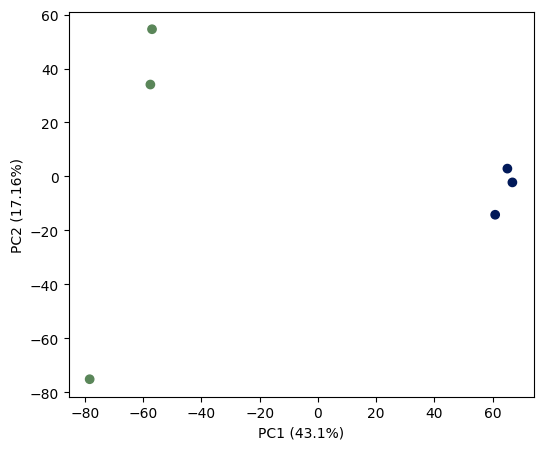

In [8]:
import matplotlib.pyplot as plt

apt.tl.pca(adata, n_comps=2)

# alphapepttools namespaces results by method + dim_space. The defaults
# (method='pca', dim_space='obs') write to:
#   adata.obsm['X_pca_obs']
#   adata.varm['PCs_pca_obs']
#   adata.uns['variance_pca_obs']  -> {'variance_ratio': [...], 'variance': [...]}
var = adata.uns["variance_pca_obs"]["variance_ratio"]
print(f"PC1 / PC2 explained variance: {var[0]*100:.1f}% / {var[1]*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 5))
apt.pl.plot_pca(adata, color_map_column="condition", ax=ax)
plt.show()


## §8. Differential analysis — limma via inmoose

`apt.tl.diff_exp_ebayes` wraps `inmoose` (pure-Python Bioconductor limma port).
Same algorithm as R limma; same numerical results to floating-point precision.
No R subprocess; works on any platform.

Pass:
- `between_column` — the obs column whose values define groups
- `comparison=(treatment, control)` — `logFC = mean(treatment) - mean(control)`,
   so positive = up in treatment

Result is a long DataFrame with columns including:
- `protein` — the site identifier (alphaPhos `PTM_Collapse_key`)
- `log2fc` — moderated log2 fold-change
- `p_value`, `fdr` — moderated-t p-value and BH-adjusted
- `stat`, `B` — moderated-t statistic, log-odds of differential expression


In [9]:
treatment, control = "woEGF", "withEGF"  # logFC = mean(treatment) - mean(control)

comp_id, results = apt.tl.diff_exp_ebayes(
    adata,
    between_column="condition",
    comparison=(treatment, control),
)

# Add significance flag (adj.P < 0.05 & |logFC| > 0.585 == ~1.5x fold-change)
results["sig"] = (results["fdr"] < 0.05) & (results["log2fc"].abs() > 0.585)

print(f"Comparison ID: {comp_id}")
print(f"Features tested: {len(results):,}")
print(f"Significant hits (FDR<0.05, |logFC|>0.585): {int(results['sig'].sum()):,}")
print(f"  up in {treatment}:   "
      f"{int(((results['sig']) & (results['log2fc'] > 0)).sum()):,}")
print(f"  up in {control}: "
      f"{int(((results['sig']) & (results['log2fc'] < 0)).sum()):,}")


Running Limma eBayes differential expression analysis via inmoose
Comparing levels: woEGF (treatment) vs withEGF (control)
Number of samples for woEGF: 3
Number of samples for withEGF: 3
pp.filter_data_completeness(): drop 0 / 17576 features with >0.00 missing.
Computing contrast: condition[woEGF]-condition[withEGF]
Design matrix dimensions: 6 samples x 2 groups
Expression matrix dimensions: 17576 proteins x 6 samples


Comparison ID: woEGF_VS_withEGF
Features tested: 17,576
Significant hits (FDR<0.05, |logFC|>0.585): 2,158
  up in woEGF:   652
  up in withEGF: 1,506


## §9. Volcano plot + top hits

Standard volcano: x = logFC, y = −log10(FDR), colored by significance.

The top hits should include the textbook EGF signaling readouts:
- **EGFR autophosphorylation sites**: Y1172, Y1197 — strong negative logFC
  in woEGF (= up under EGF) is the canonical positive control.
- **Downstream signaling**: SHC1, GAB1, CRK, PIK3 components, MAPK pathway.
- **Negative-feedback regulators**: TSC2, INPPL1, etc.


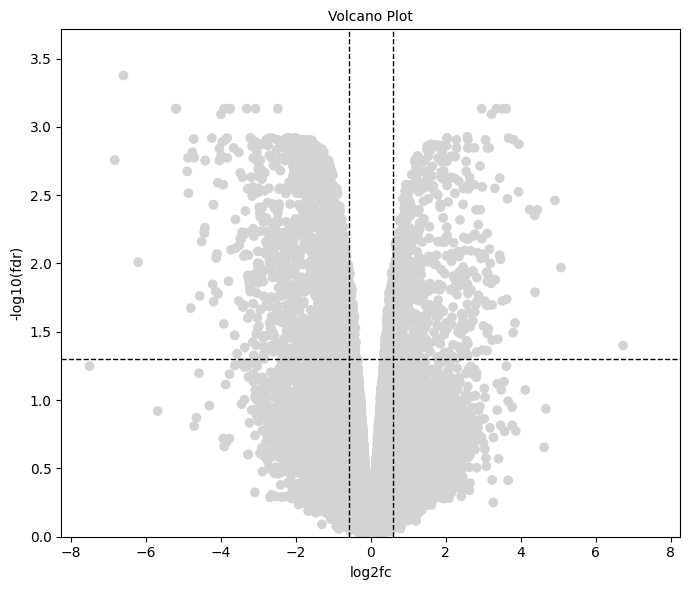

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))
apt.pl.volcano(
    results,
    x_column="log2fc",                    # results has 'log2fc' column already
    y_column="-log10(fdr)",               # FDR-axis volcano (standard for proteomics)
    x_thresholds=(-0.585, 0.585),         # |logFC| > 0.585 (~1.5x)
    y_thresholds=-np.log10(0.05),         # adj.P < 0.05
    ax=ax,
)
plt.tight_layout()
plt.show()


In [11]:
# Top 15 hits by FDR — annotate with gene/site for biology check
top = results.nsmallest(15, "fdr")[["protein", "log2fc", "p_value", "fdr"]].copy()
top["log2fc"] = top["log2fc"].round(3)
top["p_value"] = top["p_value"].apply(lambda x: f"{x:.2e}")
top["fdr"] = top["fdr"].apply(lambda x: f"{x:.2e}")
top.reset_index(drop=True, inplace=True)
top


,protein,log2fc,p_value,fdr
0,P00533~EGFR_Y1172_M1,-6.587,2.39e-08,4.21e-04
1,O15027~SEC16A_S589_M3,3.350,3.53e-07,7.37e-04
2,O15357~INPPL1_Y1135_M1,-3.769,1.58e-07,7.37e-04
3,O95785~WIZ_S1151_M1,2.959,4.93e-07,7.37e-04
4,P12270~TPR_T2137_M1,-5.196,4.98e-07,7.37e-04
5,P46108~CRK_S74_M1,-5.175,3.51e-07,7.37e-04
6,P51858~HDGF_S107_M1,-2.472,5.87e-07,7.37e-04
7,Q15418~RPS6KA1_S363_M1,3.506,5.24e-07,7.37e-04
8,Q5SW79~CEP170_S1270_M1,-3.067,5.71e-07,7.37e-04
9,Q8NG31~KNL1_S1690_M1,-3.908,3.86e-07,7.37e-04


## §10. Per-site kinase prediction (Yaffe Kinase Library)

**Per-site PWM scoring — answers: "for *this specific site*, which
kinase is the most likely regulator?"** This is sequence-based prediction
of upstream kinase(s) using the Yaffe Kinase Library PWMs (Johnson et al.
*Nature* 2023) — 311 Ser/Thr + 78 tyrosine kinases. Per-site PWM
prediction; NOT kinase activity / enrichment (that's §11).

**Prerequisite:** `kinase_sequence` must be populated in `adata.var`. That
happens automatically when you pass `fasta_path="proteome.fasta"` to
`collapse_sites()`. If your `adata` doesn't have this column, re-run §3
with a FASTA path.

Two functions:
- `score_kinases(adata)` writes the full (sites × kinases) score matrices
  to `adata.varm['kinase_score_ser_thr']` and `adata.varm['kinase_score_tyrosine']`.
- `predict_kinases(adata, top_k=5)` returns a per-site DataFrame with the
  top-k kinases. Calls `score_kinases` automatically on first run.

**What this answers:** "For *this specific site*, which kinase is most
likely the regulator?" — complementary to the network-based KSEA
question ("which kinase *activities* changed?") which is the planned
`alphaphos.ksea` module.


In [ ]:
from alphaphos.kinase import predict_kinases

# Only run if we have kinase_sequence (i.e. collapse was run with fasta_path)
if "kinase_sequence" not in adata.var.columns:
    print("Skipping — no kinase_sequence column in adata.var.")
    print("Re-run §3 with collapse_sites(..., fasta_path='proteome.fasta')")
else:
    pred = predict_kinases(adata, top_k=5)

    # Summary
    info = adata.uns["alphaphos_kinase"]
    print(f"Scored {info['n_sites_scored']:,} sites "
          f"({info['n_ser_thr_scored']:,} S/T + {info['n_tyrosine_scored']:,} Y); "
          f"{info['n_sites_dropped']:,} dropped (invalid sequences)")
    print()

    # Attach the top1 prediction to adata.var for easy filtering/coloring
    adata.var["top1_kinase"] = pred["top1_kinase"]
    adata.var["top1_kinase_score"] = pred["top1_score"]
    adata.var["kin_type"] = pred["kin_type"]

    # Show the top-15 differentially regulated sites, annotated with their
    # predicted upstream kinases
    top_hits = (results.nsmallest(15, "fdr")
                       .set_index("protein")
                       .join(pred[["top1_kinase", "top1_score", "top_kinases"]],
                             how="left")
                       [["log2fc", "fdr", "top1_kinase", "top1_score", "top_kinases"]])
    top_hits.round(3)


## §11. Kinase enrichment / KSEA (Yaffe Kinase Library)

Where §10 asked "for *this site*, which kinase?", §11 asks **"across the
whole experiment, which kinase *activities* are changed?"** This is
classical KSEA — the headline kinase-level statistic in most phospho
papers.

`alphaphos.kinase.enrichment` exposes three complementary frameworks:

- **`kinase_enrichment_from_diffexp`** — Fisher's exact, per direction
  (up- and down-regulated sites separately). Takes the diff_exp result
  as input. Returns: per-kinase log2 frequency factor + Fisher p-value,
  per direction. **Most direct equivalent of classical KSEA.**

- **`kinase_mea`** — GSEA-style (weighted Kolmogorov-Smirnov via
  `gseapy`). Operates on the full ranked list (no hard threshold).
  Returns: per-kinase NES + p-value + FDR. **Most rigorous** (uses every
  site's rank, not a binarised threshold).

- **`kinase_enrichment_binary`** — Fisher's exact, custom foreground vs
  background (e.g. for a PCA cluster, or a pathway-curated site set).

For the EGF dataset we'd expect:
- **RTK / Src-family** activity *up* (EGFR autophos drives the cascade)
- **AKT / mTOR / RSK** activity *up* (canonical EGF downstream)
- **MAPK family** (ERK1/2) activity *up* (EGF→RAS→RAF→MEK→ERK)
- Phosphatases or feedback regulators *down*


In [ ]:
from alphaphos.kinase import kinase_enrichment_from_diffexp, kinase_mea

if "kinase_sequence" not in adata.var.columns:
    print("Skipping — no kinase_sequence column (re-run §3 with fasta_path).")
else:
    # 1. Classical KSEA (Fisher per direction) — runs in seconds
    print("Running Fisher-based KSEA (kinase_enrichment_from_diffexp)...")
    ksea = kinase_enrichment_from_diffexp(
        diff_results=results,
        sequence_lookup=adata.var["kinase_sequence"],
        id_col="protein",
        lfc_col="log2fc",
        pval_col="fdr",
        lfc_thresh=0.585,
        pval_thresh=0.05,
        kl_method="percentile",
        kl_thresh=90,
    )

    # Show the top activated/inhibited kinases in each kin_type
    for kt, df_kt in ksea.items():
        print(f"\n=== {kt} — top 10 by 'most significant' direction ===")
        top = (df_kt
                 .sort_values("most_sig_fisher_adj_pval")
                 .head(10)
                 [["most_sig_direction", "most_sig_log2_freq_factor",
                   "most_sig_fisher_adj_pval", "fg_counts_upreg", "fg_counts_downreg"]])
        print(top.round(3))

    # Stash in adata.uns for downstream / sharing
    adata.uns["alphaphos_ksea_fisher"] = {k: v.copy() for k, v in ksea.items()}


In [ ]:
# 2. GSEA-style MEA — uses the full rank, no threshold. Slower (permutation).
print("Running GSEA-style MEA (kinase_mea, 1000 permutations)...")
mea = kinase_mea(
    diff_results=results,
    sequence_lookup=adata.var["kinase_sequence"],
    id_col="protein",
    rank_col="log2fc",
    kl_method="percentile",
    kl_thresh=90,
    permutation_num=1000,
    seed=42,
)

# Top activated (positive NES) and inhibited (negative NES) kinases per type
for kt, df_kt in mea.items():
    nonna = df_kt.dropna(subset=["NES"]).sort_values("NES", ascending=False)
    print(f"\n=== {kt} — MEA NES leaders ===")
    print(f"Top 10 ACTIVATED (positive NES):")
    print(nonna.head(10)[["NES", "p-value", "FDR", "Subs fraction"]].round(3))
    print(f"\nTop 10 INHIBITED (negative NES):")
    print(nonna.tail(10)[::-1][["NES", "p-value", "FDR", "Subs fraction"]].round(3))

adata.uns["alphaphos_ksea_mea"] = {k: v.copy() for k, v in mea.items()}


## §12. Network-based KSEA (Saez-Rodriguez / decoupler-py + OmniPath)

Where §11 used **sequence-based PWMs** (Yaffe Kinase Library) to identify
kinase activity, §12 uses **curated kinase-substrate databases**
(PhosphoSitePlus, SIGNOR, KEA, NetworKIN, ...) via OmniPath as the
substrate set priors, and decoupler-py's statistical methods to score
per-kinase activity.

The two approaches are complementary:

| Question | Method |
|---|---|
| "What does the *motif* around this site predict?" | PWM-based (§11) |
| "What does the *biological literature* say this site is regulated by?" | Network-based (§12) |

Both should converge on the same conclusions for well-studied pathways.
For novel sites with no DB record, §11 still works but §12 can't score
them (no substrate set to match against).

`alphaphos.ksea` exposes four methods:

- **`kinase_activity_ulm`** — Univariate Linear Model (the classical
  KSEA z-score equivalent; recommended default)
- **`kinase_activity_mlm`** — Multivariate (joint fit; controls for
  shared substrates)
- **`kinase_activity_ora`** — Over-Representation Analysis (Fisher tail)
- **`kinase_activity_gsea`** — GSEA on the full rank


In [14]:
from pathlib import Path
from alphaphos.ksea import fetch_omnipath_ks_network, kinase_activity_ulm

# 1. Fetch (and cache) the curated kinase-substrate network for human.
#    First call hits OmniPath over the network (10–30s). Subsequent calls
#    read the parquet cache.
cache = Path("D:/Projects/alphaPhos/test_data/ks_human.parquet")
net = fetch_omnipath_ks_network(
    organism="human",
    source_key="enzyme_genesymbol",
    target_id_style="uniprot",
    min_n_sources=1,        # keep all sources for max coverage
    cache_path=cache,
)
print(f"KS network: {len(net):,} edges, {net['source'].nunique():,} kinases, "
      f"{net['target'].nunique():,} unique sites")

# 2. Run ULM (the classical KSEA-z-score equivalent).
print("\nRunning network-based KSEA (ULM)...")
ksea_net = kinase_activity_ulm(
    results,                     # diff_exp result from §8
    net,
    id_col="protein",
    stat_col="log2fc",
    min_targets=5,
    convert_site_ids=True,       # alphaPhos -> OmniPath site-id conversion
)

# 3. Sort + show top activated / inhibited
top_act = ksea_net.sort_values("score", ascending=False).head(15)
top_inh = ksea_net.sort_values("score").head(15)
print("\nTop 15 ACTIVATED kinases (sorted by score desc):")
print(top_act.round(3))
print("\nTop 15 INHIBITED kinases (sorted by score asc):")
print(top_inh.round(3))

# 4. Stash in adata.uns for downstream / sharing
adata.uns["alphaphos_ksea_network_ulm"] = ksea_net.copy()


c:\Users\oliinyk\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

Fetching OmniPath Enzsub for organism=human ...
Got 41506 enzyme-substrate rows from OmniPath
Cached KS network to D:\Projects\alphaPhos\test_data\ks_human.parquet
KS network: 39019 edges, 1648 kinases, 16203 sites


KS network: 39,019 edges, 1,648 kinases, 16,203 unique sites

Running network-based KSEA (ULM)...


Network/data overlap: 2617 sites (network has 16067 targets; data has 16203)



Top 15 ACTIVATED kinases (sorted by score desc):
        score   pval  n_targets
kinase                         
CDK2    4.189  0.000        460
GSK3B   3.783  0.001        330
MARK3   2.698  0.027          7
CSNK1D  2.260  0.072         18
CDK1    2.204  0.077        428
CSNK1E  2.182  0.079         52
MARK2   2.039  0.106         13
MAPK14  1.949  0.124        249
CDK5R1  1.592  0.237          8
PRKAA1  1.474  0.285         38
CCNE2   1.388  0.321         10
ULK1    1.339  0.343         11
PRKAG2  1.192  0.413         20
PRKAG3  1.153  0.427         19
PRKAB2  1.153  0.427         19

Top 15 INHIBITED kinases (sorted by score asc):
           score  pval  n_targets
kinase                           
FLT3     -11.139   0.0          5
LCK      -10.227   0.0         15
SYK       -9.743   0.0          7
HCK       -7.413   0.0          9
PTPN2     -7.391   0.0         12
SRC       -7.024   0.0         45
PTPRG     -6.803   0.0         12
ZAP70     -6.521   0.0          5
LYN       -6.394 

## §13. Save the analysed AnnData

`adata.write_h5ad` persists everything in one HDF5 file:
- `.X` (imputed log2 quants)
- `.obs` (sample metadata)
- `.var` (per-site metadata: structural + motif flags + site QC)
- `.layers["intensity_log2"]` (the imputed quants)
- `.layers["localization"]` (per-site, per-sample loc probs)
- `.uns["alphaphos"]` (pipeline provenance)
- `.uns["pca"]` (PCA result)
- `.obsm["X_pca"]` (PCA embedding)
- `.uns["classI_decision_table"]` (the per-condition Class-I decision table)

Differential results live in their own DataFrame — save alongside.


In [ ]:
adata_path = OUT_DIR / "pipeline_walkthrough_adata.h5ad"
adata.write_h5ad(adata_path)
print(f"AnnData saved to: {adata_path}")
print(f"  size: {adata_path.stat().st_size / 1e6:.1f} MB")

results_path = OUT_DIR / "pipeline_walkthrough_results.parquet"
results.to_parquet(results_path)
print(f"Differential results saved to: {results_path}")
print(f"  size: {results_path.stat().st_size / 1e6:.1f} MB")


## What you have at this point

- `adata` — full quantitative matrix with phospho-specific metadata, ready
  for any scverse-compatible downstream tool
- `results` — differential analysis table (1 row per site)
- Two persisted files: `pipeline_walkthrough_adata.h5ad` +
  `pipeline_walkthrough_results.parquet`

## Natural next steps (none of these are shipped yet)

| What | Where it would live |
|---|---|
| Kinase activity inference (KSEA, Kinase Library) | `alphaphos.kinase` |
| Sequence motif logos + enrichment | `alphaphos.motif` |
| PhosphoSitePlus annotation enrichment | `alphaphos.annotate.phosphositeplus` |
| Per-S/T/Y stratified analysis | `alphaphos.stratify.by_aa` |
| Multiplicity-aware analysis (M1/M2/M3 co-regulation) | `alphaphos.stratify.multiplicity` |

See **`docs/benchmark/spectronaut_native_benchmark.md`** for the full validation
of every default in this pipeline against Spectronaut's native classI PTM site
report.
